### **Environment Setup (Run First)**

In [1]:
# Upgrade pip and install compatible versions
!pip install --upgrade pip
!pip install numpy==1.26.4 pandas matplotlib scikit-learn
!pip install tensorflow==2.16.1 keras

# Restart runtime to apply changes
import IPython
print("✅ Setup complete! Please RESTART the runtime (Runtime > Restart runtime) and rerun from Cell 2.")
IPython.Application.instance().kernel.do_shutdown(True)

✅ Setup complete! Please RESTART the runtime (Runtime > Restart runtime) and rerun from Cell 2.


{'status': 'ok', 'restart': True}

### **Import Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error
import math

### **Load Dataset**

In [3]:
# Sample dataset: using a public weather CSV for demo
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url, parse_dates=['Date'])

# Show first few rows
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


### **Visualize Data**

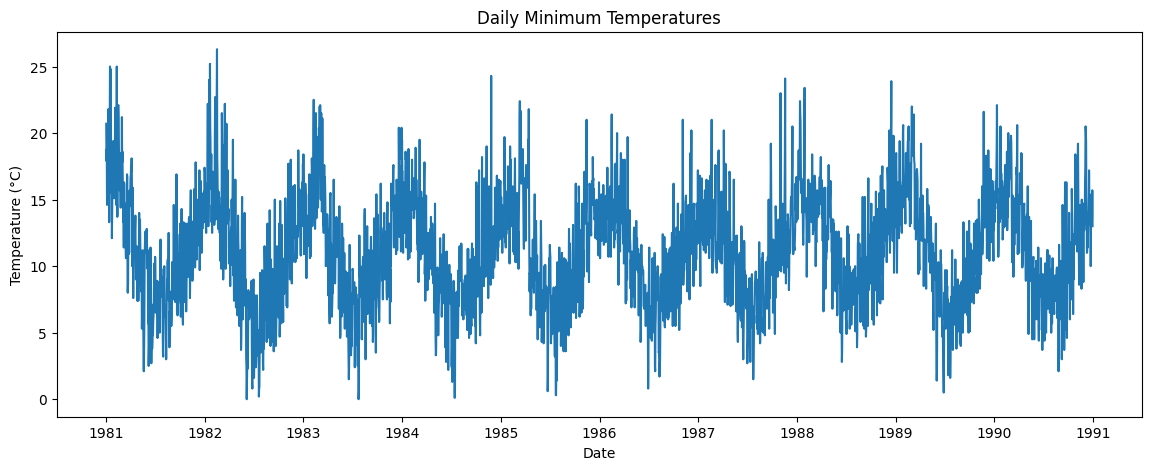

In [4]:
plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Temp'])
plt.title('Daily Minimum Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

### **Preprocess Data**

In [5]:
# Use only temperature values
data = df['Temp'].values.reshape(-1, 1)

# Scale data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# Training size (80%)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Function to create sequences
def create_dataset(dataset, time_step=30):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 30
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

# Reshape for LSTM [samples, time_steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

### **Build LSTM Model**

In [6]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

### **Train the Model**

In [7]:
history = model.fit(X_train, y_train, batch_size=32, epochs=20, validation_data=(X_test, y_test))

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0522 - val_loss: 0.0102
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0123 - val_loss: 0.0098
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0120 - val_loss: 0.0096
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0123 - val_loss: 0.0101
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0115 - val_loss: 0.0100
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0116 - val_loss: 0.0088
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0110 - val_loss: 0.0089
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0115 - val_loss: 0.0082
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0100 - val_loss: 0.0081
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0099 - val_loss: 0.0078
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0099 - val_loss: 0.0075
Epoch 12/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0

### **Evaluate the Model**

In [8]:
# Predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform to original scale
train_predict = scaler.inverse_transform(train_predict)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1,1))
test_predict = scaler.inverse_transform(test_predict)
y_test_orig = scaler.inverse_transform(y_test.reshape(-1,1))

# Calculate RMSE
train_rmse = math.sqrt(mean_squared_error(y_train_orig, train_predict))
test_rmse = math.sqrt(mean_squared_error(y_test_orig, test_predict))

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Train RMSE: 2.49
Test RMSE: 2.28


### **Plot Predictions**

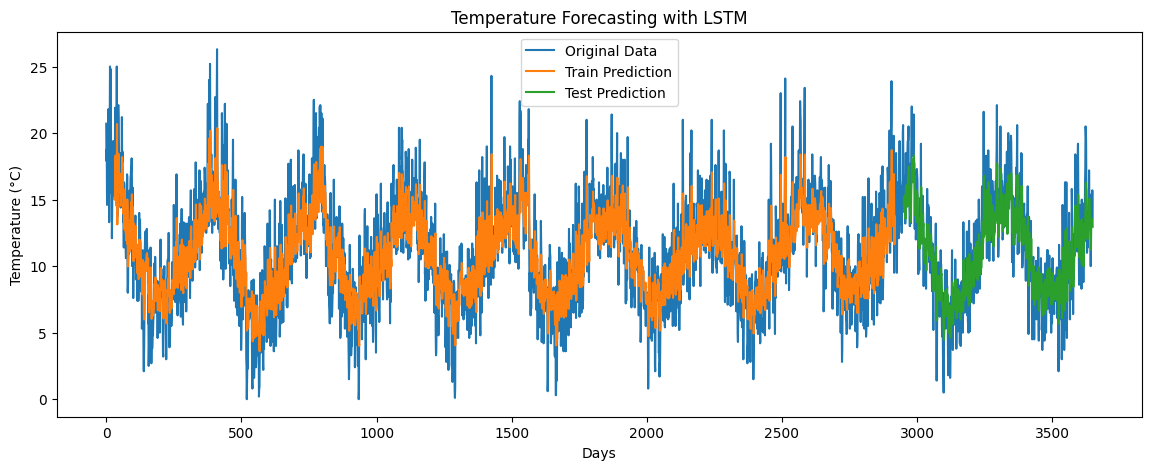

In [9]:
# Shift predictions for visualization
look_back = time_step
train_plot = np.empty_like(data)
train_plot[:, :] = np.nan
train_plot[look_back:len(train_predict)+look_back, :] = train_predict

test_plot = np.empty_like(data)
test_plot[:, :] = np.nan
test_plot[len(train_predict)+(look_back*2)+1:len(data)-1, :] = test_predict

plt.figure(figsize=(14,5))
plt.plot(scaler.inverse_transform(scaled_data), label='Original Data')
plt.plot(train_plot, label='Train Prediction')
plt.plot(test_plot, label='Test Prediction')
plt.title('Temperature Forecasting with LSTM')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

### **Forecast Future Values**

In [10]:
# Predict next 7 days
last_sequence = test_data[-time_step:]
temp_input = list(last_sequence.reshape(-1))
lst_output = []

for i in range(7):
    x_input = np.array(temp_input[-time_step:]).reshape(1, time_step, 1)
    yhat = model.predict(x_input, verbose=0)
    temp_input.append(yhat[0][0])
    lst_output.append(yhat[0][0])

# Inverse transform
forecast = scaler.inverse_transform(np.array(lst_output).reshape(-1,1))
print("7-Day Forecast:")
print(forecast.flatten())

7-Day Forecast:
[12.463806  12.510929  12.49405   12.442092  12.371693  12.294297
 12.2160845]


### **Plot Future Forecast**

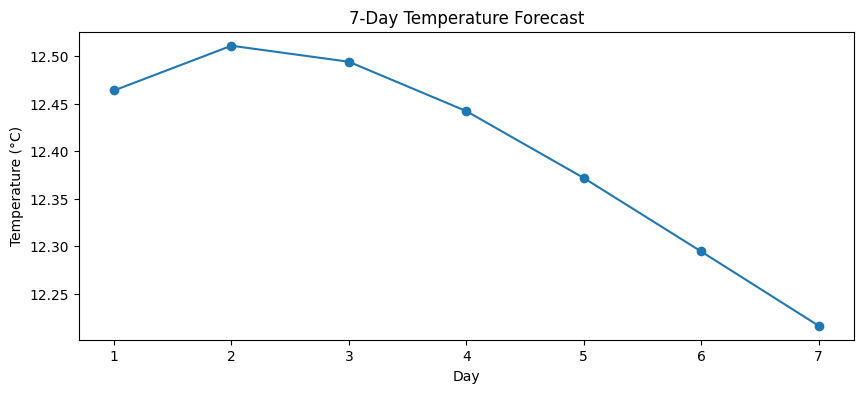

In [11]:
plt.figure(figsize=(10,4))
plt.plot(range(1,8), forecast, marker='o')
plt.title('7-Day Temperature Forecast')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.show()